In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from google.colab import drive
drive.mount('/content/drive')
# --- تحميل البيانات ---
X = np.load('/content/drive/MyDrive/alphabet/images_under.npy')
y = np.load('/content/drive/MyDrive/alphabet/encoded_labels_under.npy')

# لو الصور رمادية نكررها لثلاث قنوات
if X.shape[-1] == 1:
    X = np.repeat(X, 3, axis=-1)

# تقسيم البيانات
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

input_shape = X_train.shape[1:]
num_classes = len(np.unique(y))


Mounted at /content/drive


In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)


In [3]:
def build_mobilenetv2(input_shape, num_classes):
    base_model = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )

    # Fine-tuning: نفتح آخر 20 طبقة
    for layer in base_model.layers[:-20]:
        layer.trainable = False
    for layer in base_model.layers[-20:]:
        layer.trainable = True

    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model



🚀 Run 1/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 103s 191ms/step - accuracy: 0.1667 - loss: 3.6253 - val_accuracy: 0.4251 - val_loss: 1.8874 - learning_rate: 1.0000e-04
Epoch 2/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 38s 95ms/step - accuracy: 0.5284 - loss: 1.5643 - val_accuracy: 0.5962 - val_loss: 1.3768 - learning_rate: 1.0000e-04
Epoch 3/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 37s 92ms/step - accuracy: 0.6708 - loss: 1.0474 - val_accuracy: 0.7381 - val_loss: 0.8420 - learning_rate: 1.0000e-04
Epoch 4/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 37s 92ms/step - accuracy: 0.7497 - loss: 0.7905 - val_accuracy: 0.8049 - val_loss: 0.6275 - learning_rate: 1.0000e-04
Epoch 5/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 36s 88ms/step - accuracy: 0.8101 - loss: 0.5935 - val_accuracy: 0.8578 - val_loss: 0.4680 - learning_rate: 1.0000e-04
Epoch 6/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 36s 89ms/step - accuracy: 0.8343 - loss: 0.5204 - val_accuracy: 0.8883 - val_loss: 0.3555 - learning_rate: 1.0000e-04
Epoch 7/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 35s 88ms/s

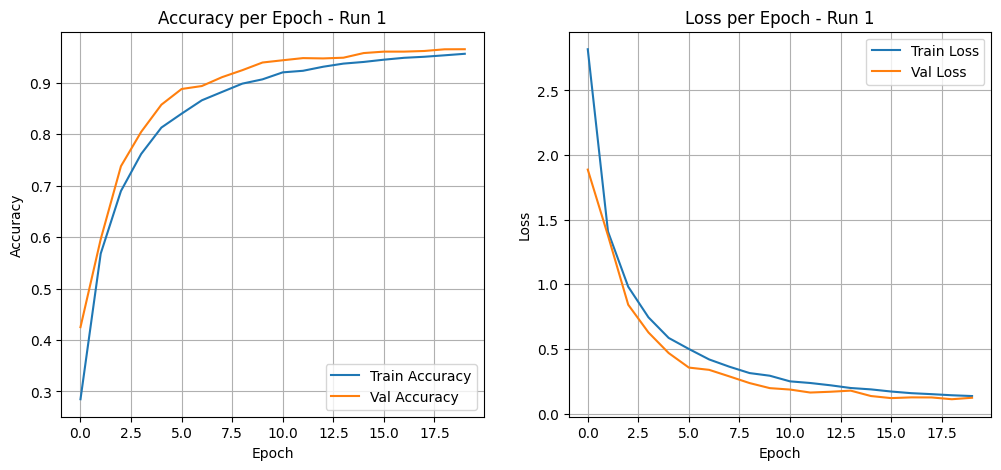

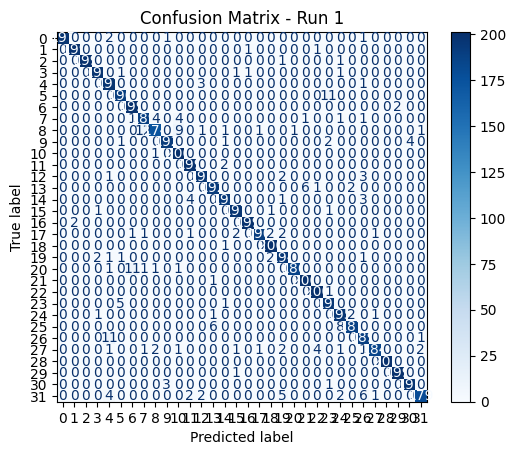


🚀 Run 2/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


402/402 ━━━━━━━━━━━━━━━━━━━━ 64s 125ms/step - accuracy: 0.1658 - loss: 3.5843 - val_accuracy: 0.4476 - val_loss: 1.8489 - learning_rate: 1.0000e-04
Epoch 2/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 35s 88ms/step - accuracy: 0.5296 - loss: 1.5568 - val_accuracy: 0.6363 - val_loss: 1.1798 - learning_rate: 1.0000e-04
Epoch 3/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 42s 91ms/step - accuracy: 0.6727 - loss: 1.0324 - val_accuracy: 0.7544 - val_loss: 0.7917 - learning_rate: 1.0000e-04
Epoch 4/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 37s 91ms/step - accuracy: 0.7501 - loss: 0.7739 - val_accuracy: 0.8164 - val_loss: 0.5683 - learning_rate: 1.0000e-04
Epoch 5/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 35s 88ms/step - accuracy: 0.8028 - loss: 0.6114 - val_accuracy: 0.8679 - val_loss: 0.3945 - learning_rate: 1.0000e-04
Epoch 6/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 37s 92ms/step - accuracy: 0.8352 - loss: 0.5077 - val_accuracy: 0.8869 - val_loss: 0.3573 - learning_rate: 1.0000e-04
Epoch 7/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 37s 91ms/step - accura

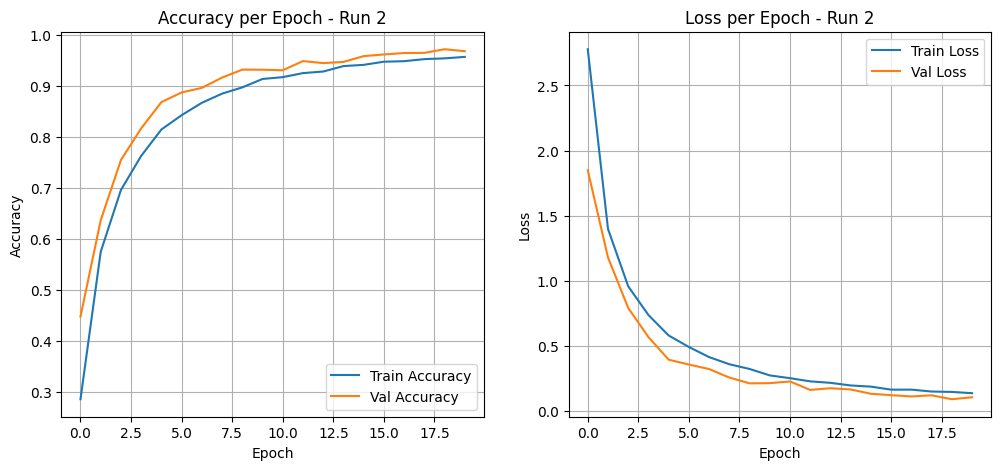

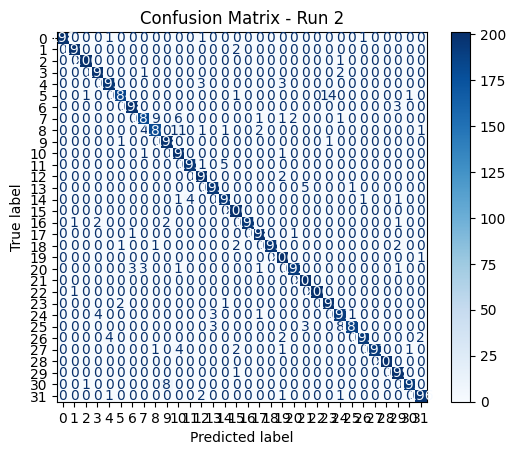


🚀 Run 3/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


402/402 ━━━━━━━━━━━━━━━━━━━━ 65s 127ms/step - accuracy: 0.1650 - loss: 3.5980 - val_accuracy: 0.4460 - val_loss: 1.8822 - learning_rate: 1.0000e-04
Epoch 2/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 37s 93ms/step - accuracy: 0.5298 - loss: 1.5662 - val_accuracy: 0.6321 - val_loss: 1.2596 - learning_rate: 1.0000e-04
Epoch 3/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 41s 93ms/step - accuracy: 0.6675 - loss: 1.0557 - val_accuracy: 0.7476 - val_loss: 0.8404 - learning_rate: 1.0000e-04
Epoch 4/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 37s 93ms/step - accuracy: 0.7508 - loss: 0.7890 - val_accuracy: 0.8028 - val_loss: 0.6263 - learning_rate: 1.0000e-04
Epoch 5/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 36s 89ms/step - accuracy: 0.7986 - loss: 0.6204 - val_accuracy: 0.8551 - val_loss: 0.4388 - learning_rate: 1.0000e-04
Epoch 6/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 37s 92ms/step - accuracy: 0.8396 - loss: 0.5100 - val_accuracy: 0.8925 - val_loss: 0.3349 - learning_rate: 1.0000e-04
Epoch 7/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 38s 95ms/step - accura

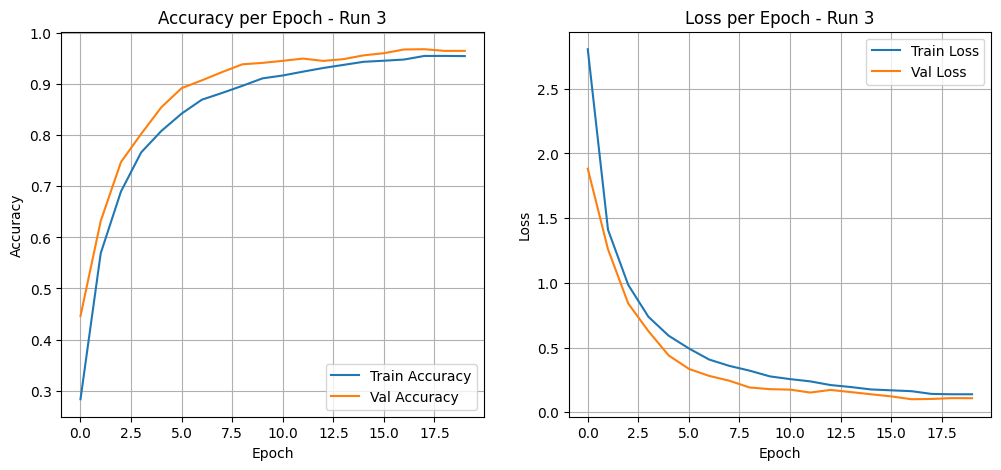

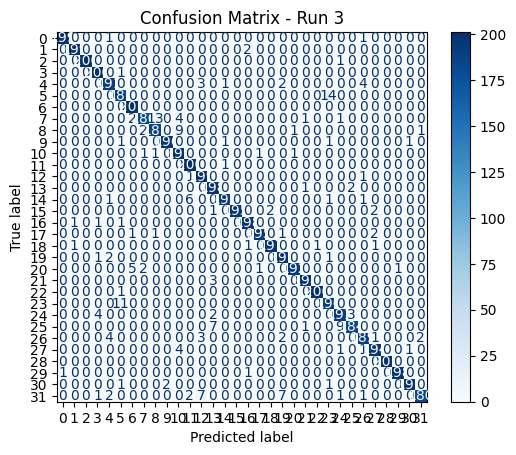


🚀 Run 4/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


402/402 ━━━━━━━━━━━━━━━━━━━━ 64s 125ms/step - accuracy: 0.1631 - loss: 3.6443 - val_accuracy: 0.3679 - val_loss: 2.4188 - learning_rate: 1.0000e-04
Epoch 2/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 37s 93ms/step - accuracy: 0.5216 - loss: 1.5908 - val_accuracy: 0.5666 - val_loss: 1.5093 - learning_rate: 1.0000e-04
Epoch 3/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 37s 92ms/step - accuracy: 0.6785 - loss: 1.0354 - val_accuracy: 0.7130 - val_loss: 0.9704 - learning_rate: 1.0000e-04
Epoch 4/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 37s 93ms/step - accuracy: 0.7466 - loss: 0.7901 - val_accuracy: 0.8178 - val_loss: 0.5857 - learning_rate: 1.0000e-04
Epoch 5/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 38s 95ms/step - accuracy: 0.7963 - loss: 0.6248 - val_accuracy: 0.8646 - val_loss: 0.4169 - learning_rate: 1.0000e-04
Epoch 6/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 38s 95ms/step - accuracy: 0.8335 - loss: 0.5210 - val_accuracy: 0.8939 - val_loss: 0.3199 - learning_rate: 1.0000e-04
Epoch 7/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 38s 95ms/step - accura

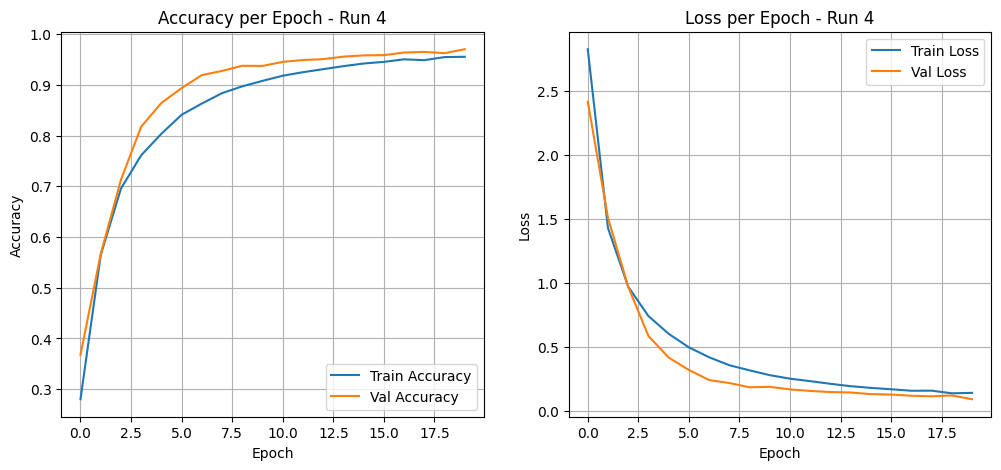

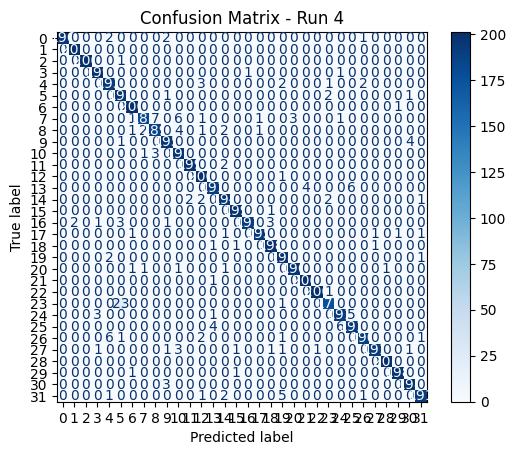


🚀 Run 5/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


402/402 ━━━━━━━━━━━━━━━━━━━━ 67s 134ms/step - accuracy: 0.1670 - loss: 3.5976 - val_accuracy: 0.4217 - val_loss: 2.0098 - learning_rate: 1.0000e-04
Epoch 2/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 40s 99ms/step - accuracy: 0.5244 - loss: 1.5789 - val_accuracy: 0.6245 - val_loss: 1.2810 - learning_rate: 1.0000e-04
Epoch 3/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 39s 97ms/step - accuracy: 0.6655 - loss: 1.0554 - val_accuracy: 0.7392 - val_loss: 0.8729 - learning_rate: 1.0000e-04
Epoch 4/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 40s 98ms/step - accuracy: 0.7546 - loss: 0.7694 - val_accuracy: 0.8005 - val_loss: 0.6445 - learning_rate: 1.0000e-04
Epoch 5/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 39s 97ms/step - accuracy: 0.8025 - loss: 0.6095 - val_accuracy: 0.8512 - val_loss: 0.4803 - learning_rate: 1.0000e-04
Epoch 6/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 38s 95ms/step - accuracy: 0.8395 - loss: 0.5042 - val_accuracy: 0.8679 - val_loss: 0.4146 - learning_rate: 1.0000e-04
Epoch 7/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 39s 97ms/step - accura

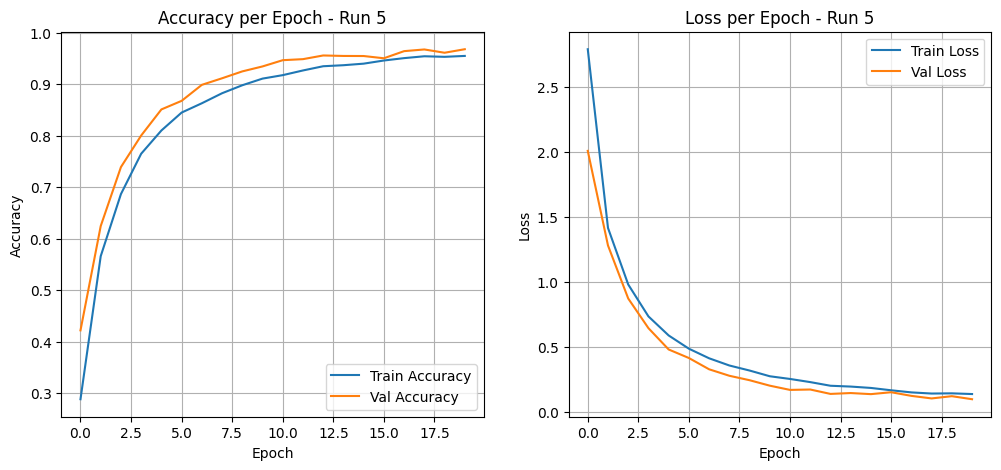

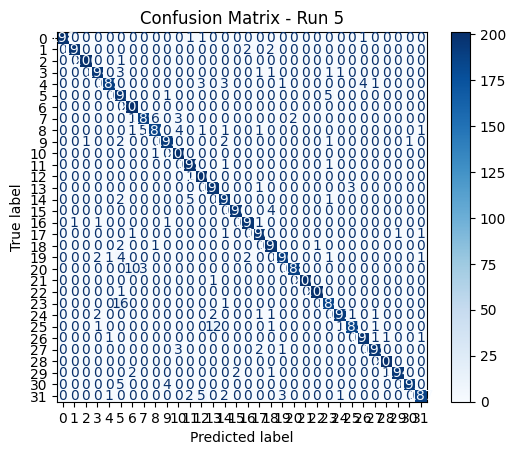


🚀 Run 6/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


402/402 ━━━━━━━━━━━━━━━━━━━━ 66s 130ms/step - accuracy: 0.1690 - loss: 3.5848 - val_accuracy: 0.4071 - val_loss: 2.1768 - learning_rate: 1.0000e-04
Epoch 2/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 39s 98ms/step - accuracy: 0.5352 - loss: 1.5421 - val_accuracy: 0.5910 - val_loss: 1.4491 - learning_rate: 1.0000e-04
Epoch 3/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 38s 95ms/step - accuracy: 0.6654 - loss: 1.0608 - val_accuracy: 0.7274 - val_loss: 0.9115 - learning_rate: 1.0000e-04
Epoch 4/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 39s 96ms/step - accuracy: 0.7481 - loss: 0.7807 - val_accuracy: 0.8268 - val_loss: 0.5427 - learning_rate: 1.0000e-04
Epoch 5/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 38s 95ms/step - accuracy: 0.8026 - loss: 0.6186 - val_accuracy: 0.8722 - val_loss: 0.3988 - learning_rate: 1.0000e-04
Epoch 6/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 40s 99ms/step - accuracy: 0.8360 - loss: 0.5019 - val_accuracy: 0.9004 - val_loss: 0.3128 - learning_rate: 1.0000e-04
Epoch 7/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 38s 95ms/step - accura

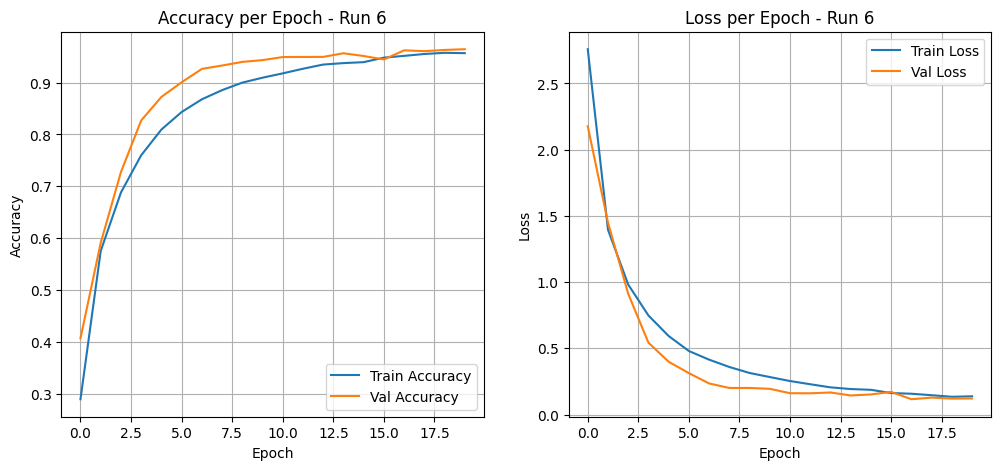

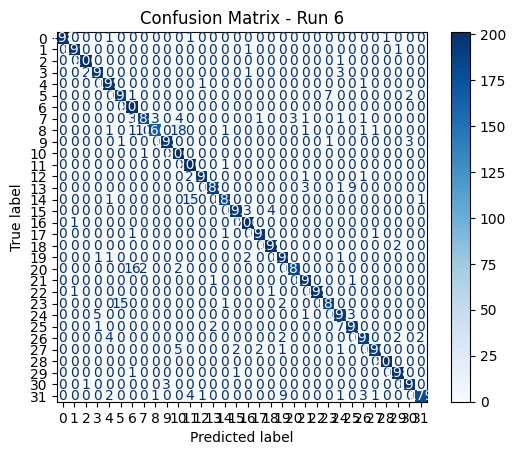


🚀 Run 7/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


402/402 ━━━━━━━━━━━━━━━━━━━━ 66s 132ms/step - accuracy: 0.1706 - loss: 3.5893 - val_accuracy: 0.3946 - val_loss: 2.2775 - learning_rate: 1.0000e-04
Epoch 2/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 39s 97ms/step - accuracy: 0.5301 - loss: 1.5657 - val_accuracy: 0.5744 - val_loss: 1.6290 - learning_rate: 1.0000e-04
Epoch 3/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 39s 98ms/step - accuracy: 0.6724 - loss: 1.0626 - val_accuracy: 0.7183 - val_loss: 0.9693 - learning_rate: 1.0000e-04
Epoch 4/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.7497 - loss: 0.7952 - val_accuracy: 0.7901 - val_loss: 0.7209 - learning_rate: 1.0000e-04
Epoch 5/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 39s 97ms/step - accuracy: 0.8016 - loss: 0.6256 - val_accuracy: 0.8484 - val_loss: 0.4830 - learning_rate: 1.0000e-04
Epoch 6/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 39s 97ms/step - accuracy: 0.8337 - loss: 0.5128 - val_accuracy: 0.8660 - val_loss: 0.4357 - learning_rate: 1.0000e-04
Epoch 7/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 38s 96ms/step - accura

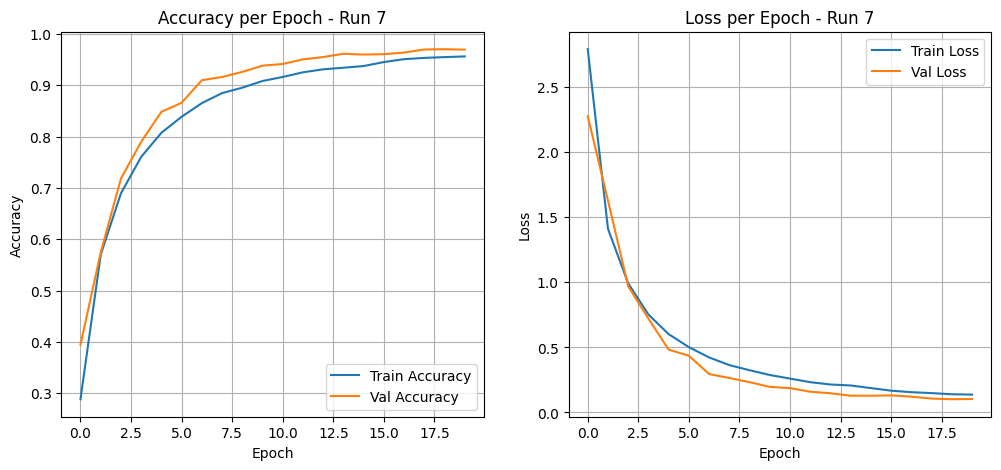

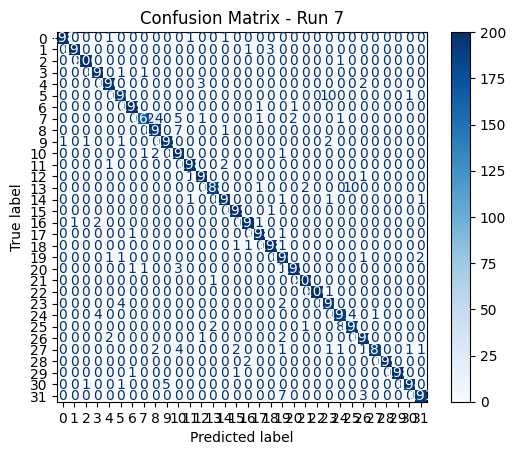


🚀 Run 8/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


402/402 ━━━━━━━━━━━━━━━━━━━━ 66s 132ms/step - accuracy: 0.1667 - loss: 3.5613 - val_accuracy: 0.4426 - val_loss: 1.8893 - learning_rate: 1.0000e-04
Epoch 2/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 63s 100ms/step - accuracy: 0.5321 - loss: 1.5619 - val_accuracy: 0.6298 - val_loss: 1.2449 - learning_rate: 1.0000e-04
Epoch 3/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 39s 98ms/step - accuracy: 0.6776 - loss: 1.0332 - val_accuracy: 0.7277 - val_loss: 0.8901 - learning_rate: 1.0000e-04
Epoch 4/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 39s 98ms/step - accuracy: 0.7489 - loss: 0.7801 - val_accuracy: 0.8128 - val_loss: 0.5819 - learning_rate: 1.0000e-04
Epoch 5/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 41s 99ms/step - accuracy: 0.7962 - loss: 0.6305 - val_accuracy: 0.8528 - val_loss: 0.4484 - learning_rate: 1.0000e-04
Epoch 6/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 40s 99ms/step - accuracy: 0.8318 - loss: 0.5186 - val_accuracy: 0.8789 - val_loss: 0.3664 - learning_rate: 1.0000e-04
Epoch 7/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 39s 98ms/step - accur

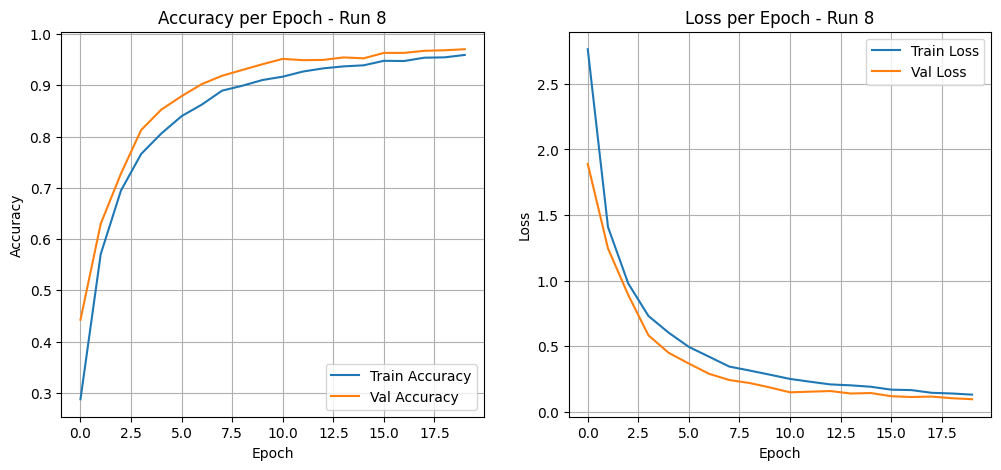

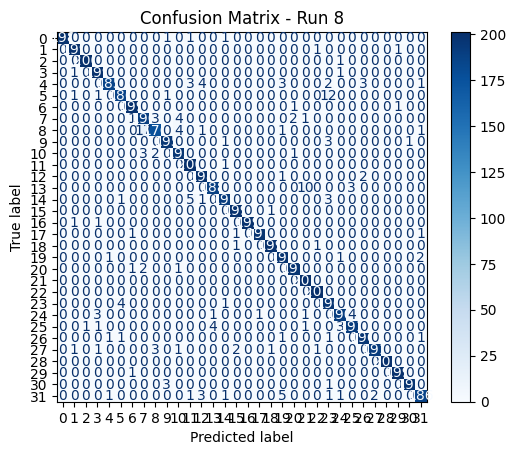


🚀 Run 9/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


402/402 ━━━━━━━━━━━━━━━━━━━━ 66s 131ms/step - accuracy: 0.1630 - loss: 3.6674 - val_accuracy: 0.4135 - val_loss: 2.0032 - learning_rate: 1.0000e-04
Epoch 2/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 40s 100ms/step - accuracy: 0.5374 - loss: 1.5562 - val_accuracy: 0.5755 - val_loss: 1.4637 - learning_rate: 1.0000e-04
Epoch 3/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 40s 100ms/step - accuracy: 0.6739 - loss: 1.0413 - val_accuracy: 0.7023 - val_loss: 0.9860 - learning_rate: 1.0000e-04
Epoch 4/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 41s 101ms/step - accuracy: 0.7491 - loss: 0.7926 - val_accuracy: 0.7955 - val_loss: 0.6475 - learning_rate: 1.0000e-04
Epoch 5/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 40s 101ms/step - accuracy: 0.7949 - loss: 0.6327 - val_accuracy: 0.8349 - val_loss: 0.5468 - learning_rate: 1.0000e-04
Epoch 6/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 40s 100ms/step - accuracy: 0.8347 - loss: 0.5173 - val_accuracy: 0.8536 - val_loss: 0.4789 - learning_rate: 1.0000e-04
Epoch 7/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 41s 101ms/step - 

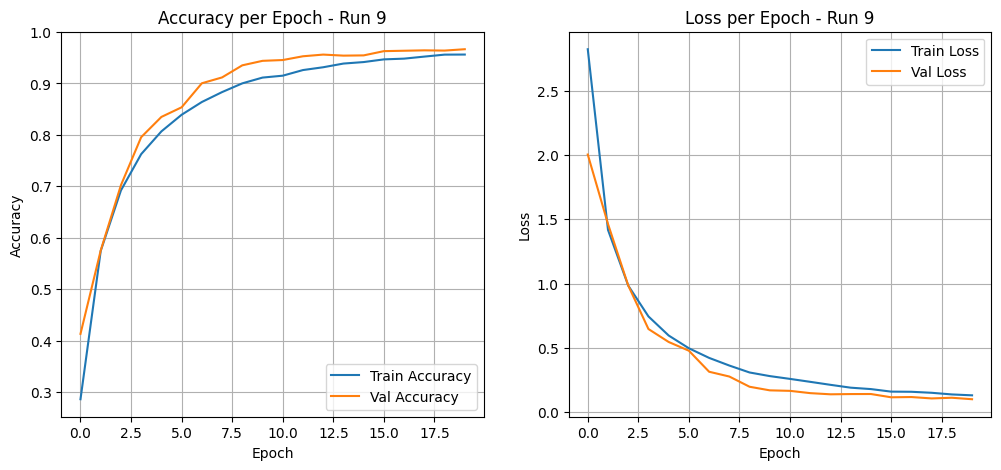

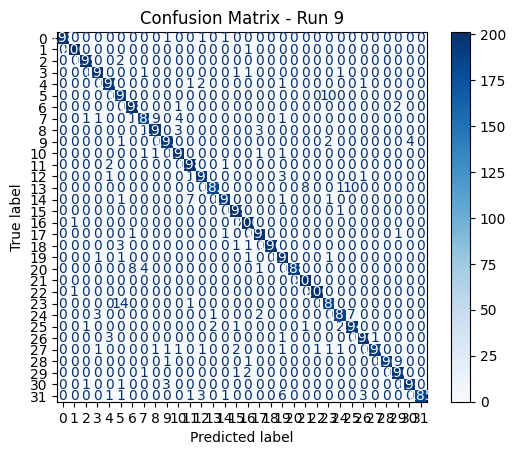


🚀 Run 10/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


402/402 ━━━━━━━━━━━━━━━━━━━━ 68s 136ms/step - accuracy: 0.1650 - loss: 3.5990 - val_accuracy: 0.4385 - val_loss: 1.8868 - learning_rate: 1.0000e-04
Epoch 2/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 41s 101ms/step - accuracy: 0.5330 - loss: 1.5329 - val_accuracy: 0.6309 - val_loss: 1.1780 - learning_rate: 1.0000e-04
Epoch 3/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 40s 100ms/step - accuracy: 0.6728 - loss: 1.0380 - val_accuracy: 0.7333 - val_loss: 0.8342 - learning_rate: 1.0000e-04
Epoch 4/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 40s 101ms/step - accuracy: 0.7510 - loss: 0.7906 - val_accuracy: 0.8114 - val_loss: 0.5636 - learning_rate: 1.0000e-04
Epoch 5/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 40s 100ms/step - accuracy: 0.8052 - loss: 0.6138 - val_accuracy: 0.8392 - val_loss: 0.5070 - learning_rate: 1.0000e-04
Epoch 6/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 41s 100ms/step - accuracy: 0.8383 - loss: 0.4893 - val_accuracy: 0.8889 - val_loss: 0.3336 - learning_rate: 1.0000e-04
Epoch 7/20
402/402 ━━━━━━━━━━━━━━━━━━━━ 40s 99ms/step - a

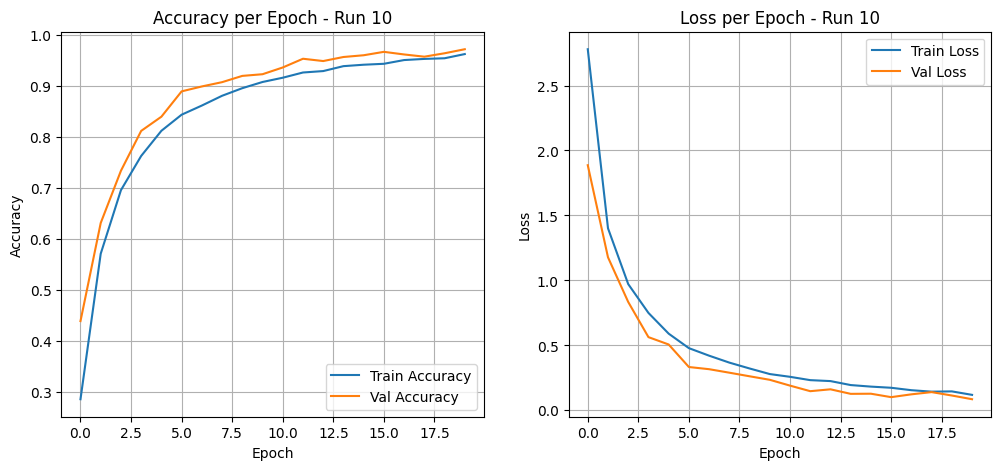

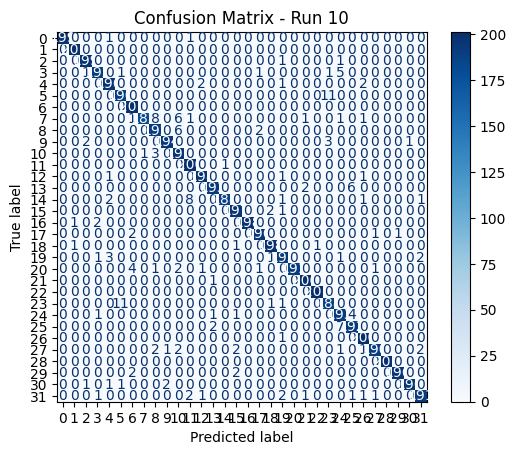


✅ جميع النتائج بعد 10 Runs:
   Run  Val_Accuracy  Val_Loss       MCC   ROC_AUC  F1_Weighted  \
0    1      0.965453  0.110816  0.964365  0.999724     0.965369   
1    2      0.971522  0.091035  0.970625  0.999833     0.971485   
2    3      0.968254  0.100382  0.967249  0.999754     0.968221   
3    4      0.970588  0.091175  0.969661  0.999808     0.970568   
4    5      0.968254  0.097371  0.967257  0.999803     0.968360   
5    6      0.962029  0.115851  0.960854  0.999685     0.961901   
6    7      0.970433  0.101463  0.969506  0.999709     0.970406   
7    8      0.970433  0.094497  0.969499  0.999768     0.970392   
8    9      0.966387  0.102048  0.965325  0.999809     0.966398   
9   10      0.971522  0.085787  0.970619  0.999828     0.971537   

   Precision_Weighted  Recall_Weighted  Training_Time(s)  Memory_Used(MB)  
0            0.966115         0.965453        802.612836      1312.769531  
1            0.972107         0.971522        773.800647       538.839844  
2    

In [4]:
import gc, time, psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow.keras.backend as K
from sklearn.metrics import (matthews_corrcoef, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score, precision_score, recall_score)
from sklearn.preprocessing import label_binarize
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

results = []

for run in range(1, 11):  # 10 runs
    print(f"\n🚀 Run {run}/10")

    # --- قياس الوقت والذاكرة قبل التدريب ---
    start_time = time.time()
    start_mem = psutil.Process().memory_info().rss / (1024 ** 2)  # MB

    # --- بناء الموديل ---
    model = build_mobilenetv2(input_shape, num_classes)

    early_stop = EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss')
    lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0)

    # --- تدريب الموديل ---
    history = model.fit(
        datagen.flow(X_train, y_train, batch_size=64),
        validation_data=(X_val, y_val),
        epochs=20,
        callbacks=[early_stop, lr_reduce],
        verbose=1
    )

    # --- قياس الوقت والذاكرة بعد التدريب ---
    end_time = time.time()
    end_mem = psutil.Process().memory_info().rss / (1024 ** 2)
    train_time = end_time - start_time
    train_memory = end_mem - start_mem

    # --- تقييم الموديل ---
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

    # --- تنبؤ ---
    y_pred_probs = model.predict(X_val, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # --- MCC ---
    mcc = matthews_corrcoef(y_val, y_pred)

    # --- ROC AUC ---
    y_val_bin = label_binarize(y_val, classes=np.arange(num_classes))
    try:
        roc_auc = roc_auc_score(y_val_bin, y_pred_probs, average='macro', multi_class='ovr')
    except:
        roc_auc = np.nan

    # --- Weighted Metrics ---
    f1_w = f1_score(y_val, y_pred, average='weighted')
    precision_w = precision_score(y_val, y_pred, average='weighted')
    recall_w = recall_score(y_val, y_pred, average='weighted')

    # --- حفظ النتيجة ---
    run_result = {
        "Run": run,
        "Val_Accuracy": val_acc,
        "Val_Loss": val_loss,
        "MCC": mcc,
        "ROC_AUC": roc_auc,
        "F1_Weighted": f1_w,
        "Precision_Weighted": precision_w,
        "Recall_Weighted": recall_w,
        "Training_Time(s)": train_time,
        "Memory_Used(MB)": train_memory
    }
    results.append(run_result)

    print(f"\n📊 Results Run {run}: "
          f"Acc={val_acc:.4f}, Loss={val_loss:.4f}, MCC={mcc:.4f}, "
          f"ROC_AUC={roc_auc:.4f}, F1={f1_w:.4f}, "
          f"Prec={precision_w:.4f}, Recall={recall_w:.4f}, "
          f"Time={train_time:.2f}s, Mem={train_memory:.2f}MB")

    # --- رسم Accuracy و Loss لكل Epoch ---
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'Accuracy per Epoch - Run {run}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'Loss per Epoch - Run {run}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - Run {run}")
    plt.show()

    # --- تنظيف الميموري ---
    del model, history, y_pred, y_pred_probs
    K.clear_session()
    gc.collect()

# --- تحويل ل DataFrame ---
df_results = pd.DataFrame(results)
print("\n✅ جميع النتائج بعد 10 Runs:")
print(df_results)

# --- حفظ النتائج ---
df_results.to_excel("mobilenetv2_metrics_results.xlsx", index=False)
print("\n💾 Saved to mobilenetv2_metrics_results.xlsx")


In [ ]:
df_results = pd.DataFrame(results)
df_results.to_excel('/content/drive/MyDrive/Mobilenet_Under.xlsx', index=False)
print("✅ Results saved to CNN_Lstm_under_analysis.xlsx")
print(df_results)


✅ Results saved to CNN_Lstm_under_analysis.xlsx
   Run  Val_Accuracy  Val_Loss       MCC   ROC_AUC  F1_Weighted  \
0    1      0.969966  0.098850  0.969022  0.999781     0.969993   
1    2      0.967009  0.106081  0.965981  0.999778     0.966887   
2    3      0.965297  0.110569  0.964213  0.999757     0.965347   
3    4      0.969032  0.100131  0.968072  0.999802     0.969006   
4    5      0.971366  0.086578  0.970465  0.999819     0.971334   
5    6      0.971366  0.096508  0.970466  0.999781     0.971418   
6    7      0.966698  0.096945  0.965644  0.999813     0.966690   
7    8      0.971366  0.092812  0.970453  0.999754     0.971399   
8    9      0.971833  0.097009  0.970936  0.999782     0.971791   
9   10      0.969655  0.104773  0.968696  0.999734     0.969642   

   Precision_Weighted  Recall_Weighted  Training_Time(s)  Memory_Used(MB)  
0            0.970772         0.969966        772.689698      1325.367188  
1            0.967903         0.967009        753.819622      

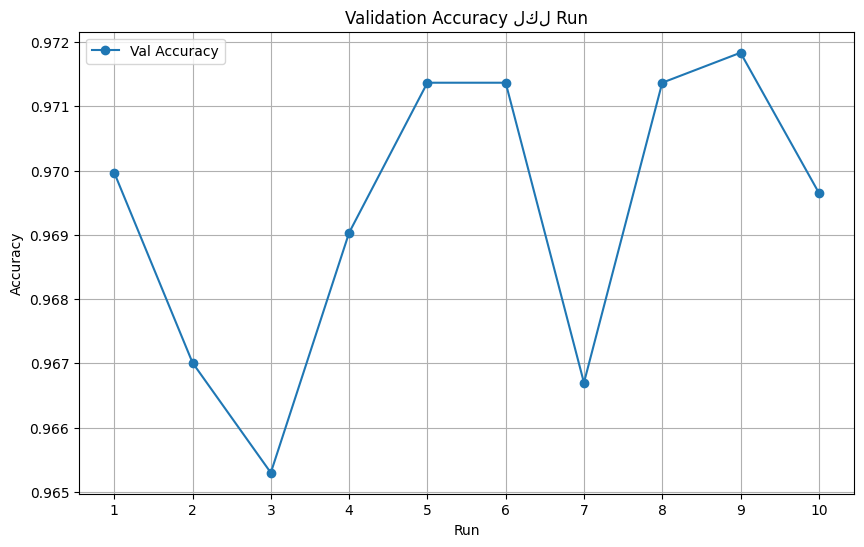

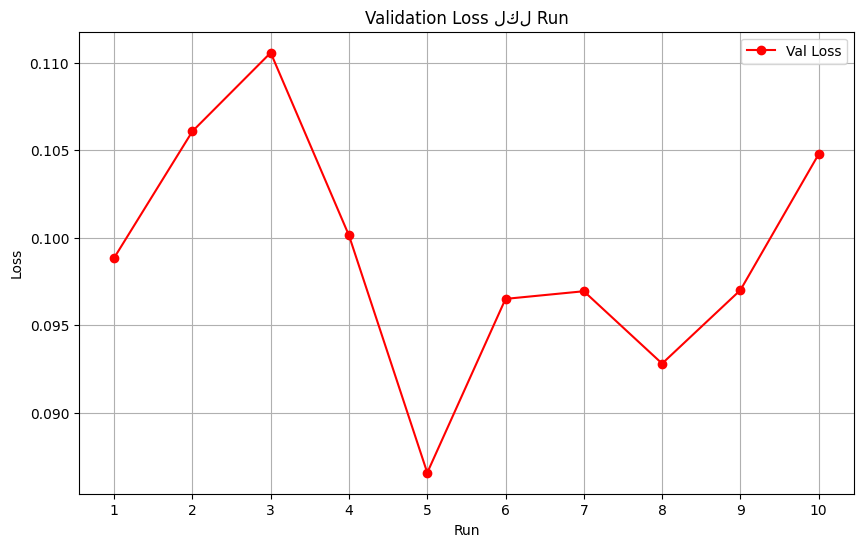

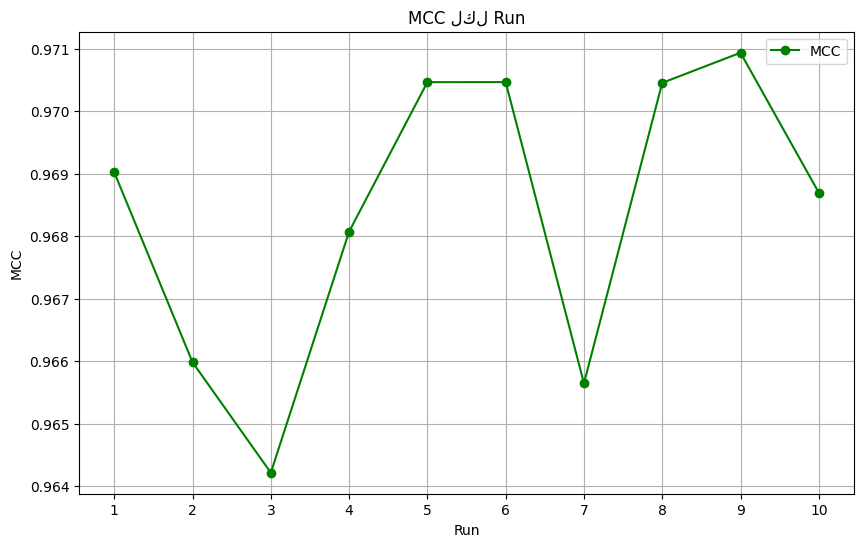

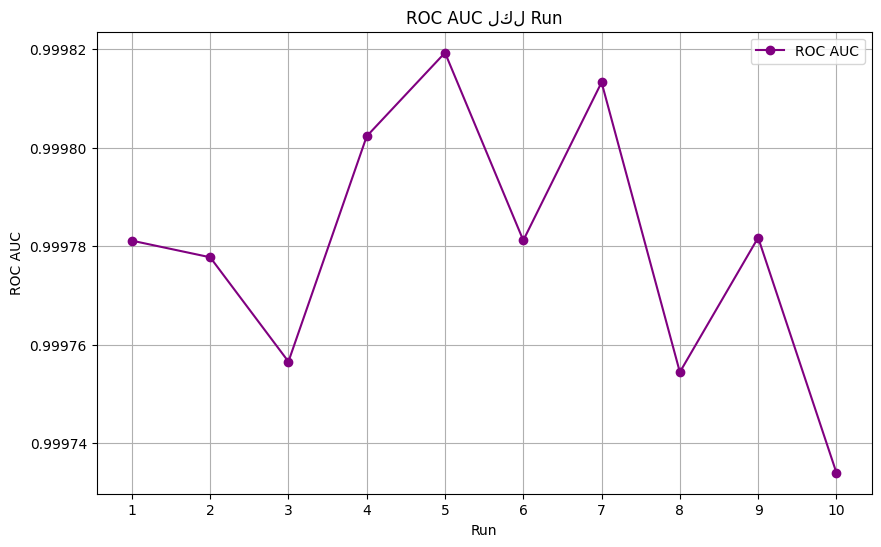

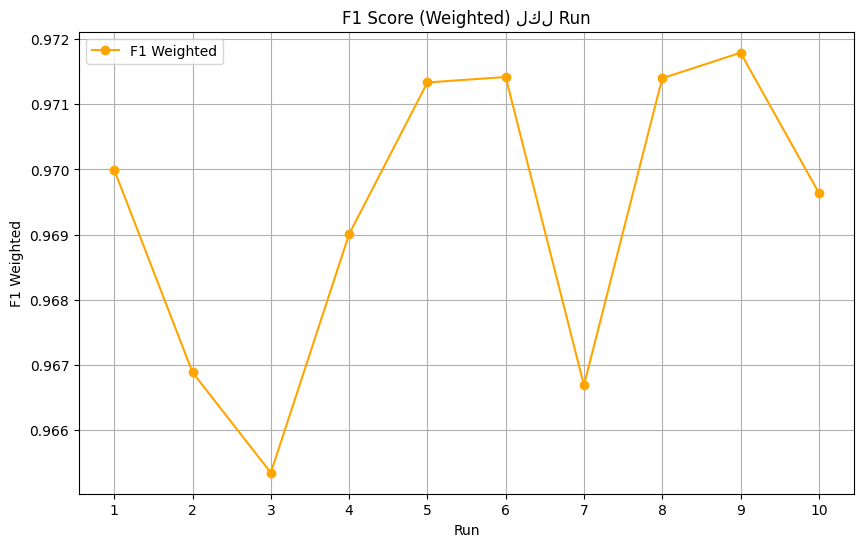

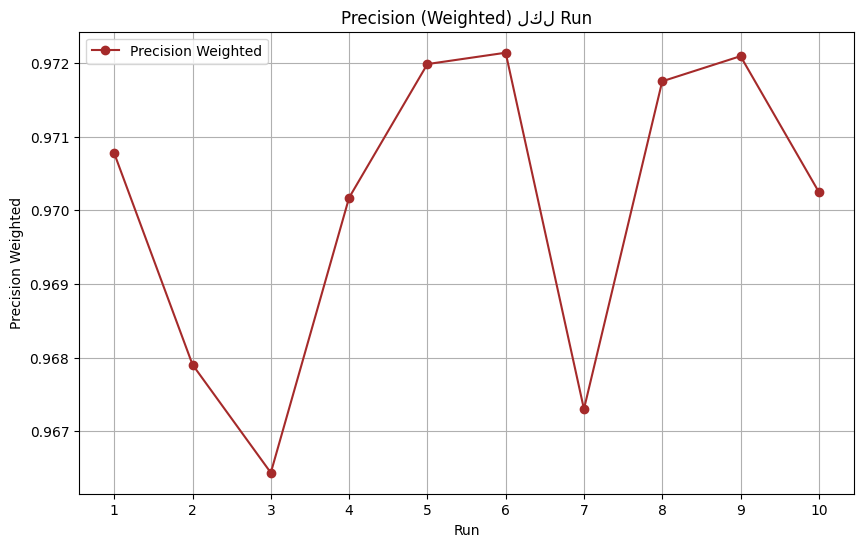

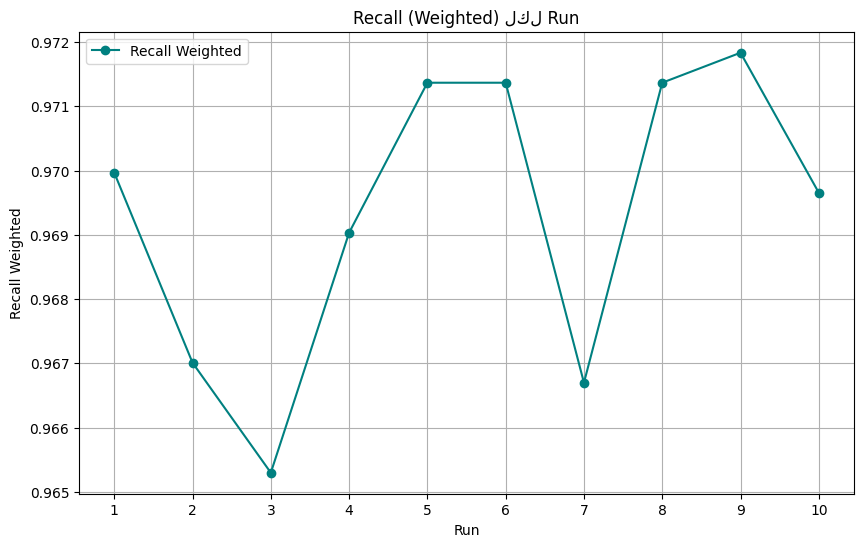

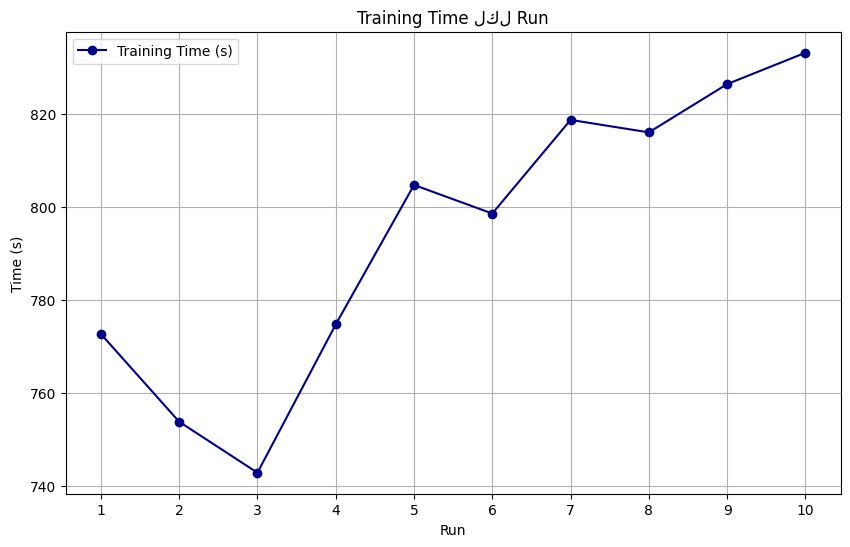

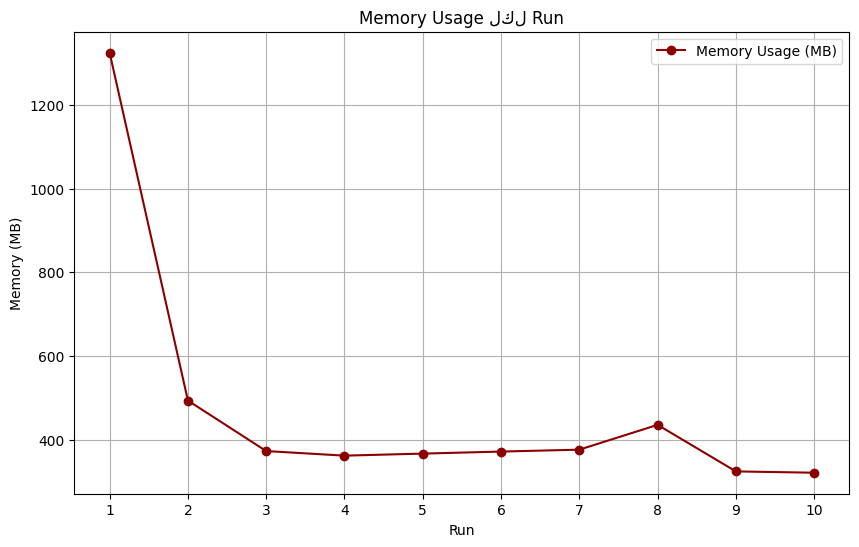

In [ ]:
import matplotlib.pyplot as plt

# --- رسم Accuracy لكل رن ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Run'], df_results['Val_Accuracy'], marker='o', label='Val Accuracy')
plt.title("Validation Accuracy لكل Run")
plt.xlabel("Run")
plt.ylabel("Accuracy")
plt.xticks(df_results['Run'])
plt.grid(True)
plt.legend()
plt.show()

# --- رسم Loss لكل رن ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Run'], df_results['Val_Loss'], marker='o', color='red', label='Val Loss')
plt.title("Validation Loss لكل Run")
plt.xlabel("Run")
plt.ylabel("Loss")
plt.xticks(df_results['Run'])
plt.grid(True)
plt.legend()
plt.show()

# --- رسم MCC لكل رن ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Run'], df_results['MCC'], marker='o', color='green', label='MCC')
plt.title("MCC لكل Run")
plt.xlabel("Run")
plt.ylabel("MCC")
plt.xticks(df_results['Run'])
plt.grid(True)
plt.legend()
plt.show()

# --- رسم ROC_AUC لكل رن ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Run'], df_results['ROC_AUC'], marker='o', color='purple', label='ROC AUC')
plt.title("ROC AUC لكل Run")
plt.xlabel("Run")
plt.ylabel("ROC AUC")
plt.xticks(df_results['Run'])
plt.grid(True)
plt.legend()
plt.show()
# --- رسم F1 لكل رن ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Run'], df_results['F1_Weighted'], marker='o', color='orange', label='F1 Weighted')
plt.title("F1 Score (Weighted) لكل Run")
plt.xlabel("Run")
plt.ylabel("F1 Weighted")
plt.xticks(df_results['Run'])
plt.grid(True)
plt.legend()
plt.show()

# --- رسم Precision لكل رن ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Run'], df_results['Precision_Weighted'], marker='o', color='brown', label='Precision Weighted')
plt.title("Precision (Weighted) لكل Run")
plt.xlabel("Run")
plt.ylabel("Precision Weighted")
plt.xticks(df_results['Run'])
plt.grid(True)
plt.legend()
plt.show()

# --- رسم Recall لكل رن ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Run'], df_results['Recall_Weighted'], marker='o', color='teal', label='Recall Weighted')
plt.title("Recall (Weighted) لكل Run")
plt.xlabel("Run")
plt.ylabel("Recall Weighted")
plt.xticks(df_results['Run'])
plt.grid(True)
plt.legend()
plt.show()

# --- رسم Training Time لكل رن ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Run'], df_results['Training_Time(s)'], marker='o', color='darkblue', label='Training Time (s)')
plt.title("Training Time لكل Run")
plt.xlabel("Run")
plt.ylabel("Time (s)")
plt.xticks(df_results['Run'])
plt.grid(True)
plt.legend()
plt.show()

# --- رسم Memory Usage لكل رن ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Run'], df_results['Memory_Used(MB)'], marker='o', color='darkred', label='Memory Usage (MB)')
plt.title("Memory Usage لكل Run")
plt.xlabel("Run")
plt.ylabel("Memory (MB)")
plt.xticks(df_results['Run'])
plt.grid(True)
plt.legend()
plt.show()



📊 Average Results across all runs:
Average Accuracy          : 0.9694
Average Loss              : 0.0990
Average MCC               : 0.9684
Average ROC AUC           : 0.9998
Average F1_Weighted       : 0.9694
Average Precision_Weighted: 0.9701
Average Recall_Weighted   : 0.9694
Average Training Time (s) : 794.17
Average Memory Used (MB)  : 474.68

✅ Results saved to /content/drive/MyDrive/alphabet/mobilenet_results_over_average.xlsx


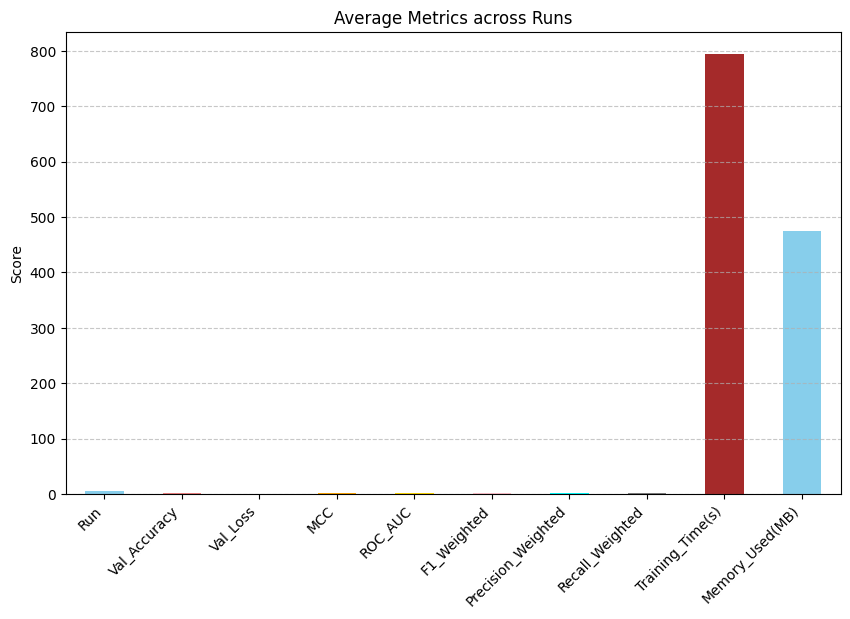

In [ ]:
import matplotlib.pyplot as plt

# --- مجموعة 1: Accuracy, Loss, ROC_AUC, MCC ---
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Accuracy
axs[0, 0].plot(df_results['Run'], df_results['Val_Accuracy'], marker='o', label='Val Accuracy')
axs[0, 0].set_title("Validation Accuracy")
axs[0, 0].set_xlabel("Run")
axs[0, 0].set_ylabel("Accuracy")
axs[0, 0].grid(True)
axs[0, 0].legend()

# Loss
axs[0, 1].plot(df_results['Run'], df_results['Val_Loss'], marker='o', color='red', label='Val Loss')
axs[0, 1].set_title("Validation Loss")
axs[0, 1].set_xlabel("Run")
axs[0, 1].set_ylabel("Loss")
axs[0, 1].grid(True)
axs[0, 1].legend()

# MCC
axs[1, 0].plot(df_results['Run'], df_results['MCC'], marker='o', color='green', label='MCC')
axs[1, 0].set_title("MCC")
axs[1, 0].set_xlabel("Run")
axs[1, 0].set_ylabel("MCC")
axs[1, 0].grid(True)
axs[1, 0].legend()

# ROC_AUC
axs[1, 1].plot(df_results['Run'], df_results['ROC_AUC'], marker='o', color='purple', label='ROC AUC')
axs[1, 1].set_title("ROC AUC")
axs[1, 1].set_xlabel("Run")
axs[1, 1].set_ylabel("ROC AUC")
axs[1, 1].grid(True)
axs[1, 1].legend()

plt.tight_layout()
plt.show()


# --- مجموعة 2: باقي المقاييس ---
fig, axs = plt.subplots(3, 2, figsize=(14, 12))

# F1
axs[0, 0].plot(df_results['Run'], df_results['F1_Weighted'], marker='o', color='orange', label='F1 Weighted')
axs[0, 0].set_title("F1 Score (Weighted)")
axs[0, 0].grid(True)
axs[0, 0].legend()

# Precision
axs[0, 1].plot(df_results['Run'], df_results['Precision_Weighted'], marker='o', color='brown', label='Precision Weighted')
axs[0, 1].set_title("Precision (Weighted)")
axs[0, 1].grid(True)
axs[0, 1].legend()

# Recall
axs[1, 0].plot(df_results['Run'], df_results['Recall_Weighted'], marker='o', color='teal', label='Recall Weighted')
axs[1, 0].set_title("Recall (Weighted)")
axs[1, 0].grid(True)
axs[1, 0].legend()

# Training Time
axs[1, 1].plot(df_results['Run'], df_results['Training_Time(s)'], marker='o', color='darkblue', label='Training Time (s)')
axs[1, 1].set_title("Training Time")
axs[1, 1].grid(True)
axs[1, 1].legend()

# Memory Usage
axs[2, 0].plot(df_results['Run'], df_results['Memory_Used(MB)'], marker='o', color='darkred', label='Memory Usage (MB)')
axs[2, 0].set_title("Memory Usage")
axs[2, 0].grid(True)
axs[2, 0].legend()

# إخفاء subplot الفاضي
axs[2, 1].axis('off')

plt.tight_layout()
plt.show()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 13.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=468060f647d91c18e4d8dd6030be7b3a7d7d515d95b845f3b603e4165c7cfc94
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
📐 Sequential Input Shape: T=10 × 64x64x1


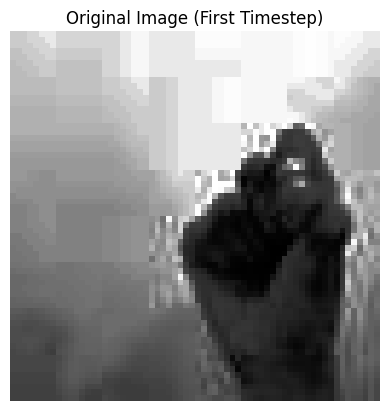

Predicted class: fa (0.90)


  0%|          | 0/1000 [00:00<?, ?it/s]

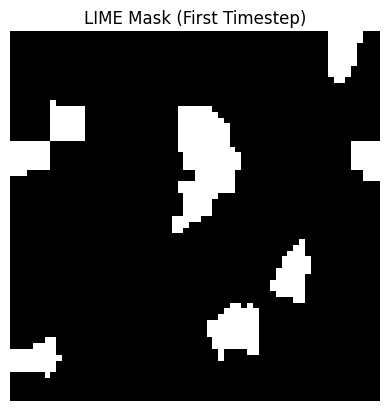

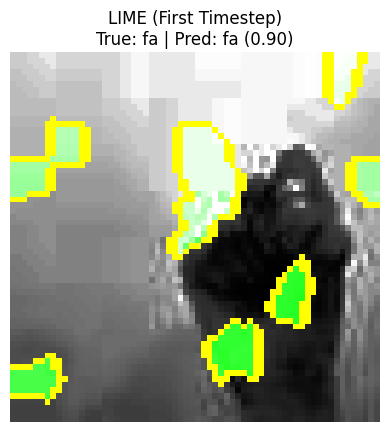

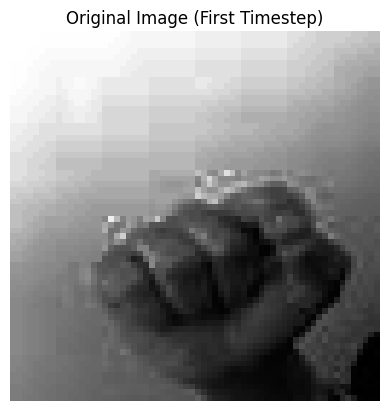

Predicted class: fa (0.99)


  0%|          | 0/1000 [00:00<?, ?it/s]

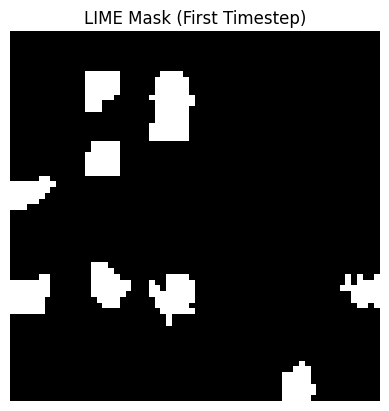

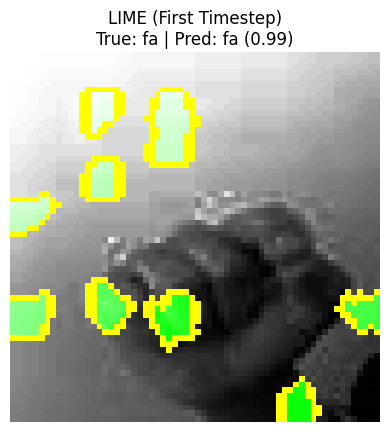

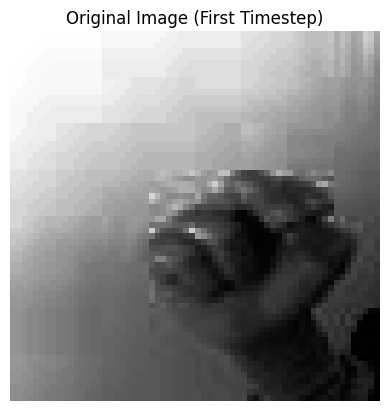

Predicted class: gaaf (0.98)


  0%|          | 0/1000 [00:00<?, ?it/s]

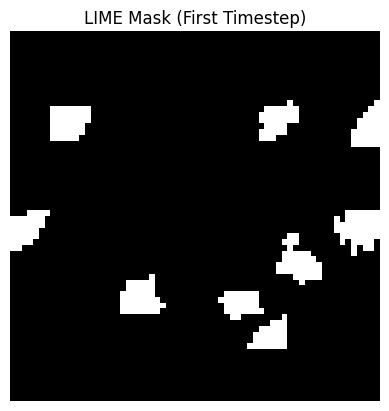

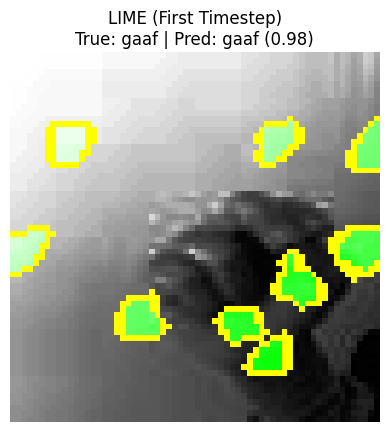

In [ ]:
!pip install lime
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic
from skimage.transform import resize
from skimage.color import rgb2gray  # Add for grayscale conversion

# تحميل أسماء الكلاسات
class_names = np.load('/content/drive/MyDrive/label_encoder_classes.npy', allow_pickle=True)

# استخراج شكل مدخلات الموديل
full_input_shape = model.input_shape  # e.g., (None, 10, 64, 64, 1)
input_shape = full_input_shape[1:]    # Remove batch dim: e.g., (10, 64, 64, 1)

T = 1
if len(input_shape) == 4 and input_shape[0] == 10 and input_shape[-1] == 1:
    T, H, W, C = input_shape  # T=10 timesteps, H/W=64, C=1 (grayscale)
    print(f"📐 Sequential Input Shape: T={T} × {H}x{W}x{C}")
elif len(input_shape) == 1:
    # 1D input (flattened): infer H, W, C assuming square grayscale (C=1) or adjust as needed
    features = input_shape[0]
    H = int(np.sqrt(features))  # Assume square; adjust if rectangular
    W = H
    C = 1  # Grayscale; set to 3 if flattened RGB
    print(f"📐 Inferred Input Shape (flattened): T={T} × {H}x{W}x{C} (total features: {features})")
elif len(input_shape) == 3:
    H, W, C = input_shape
    print(f"📐 Input Shape: T={T} × {H}x{W}x{C}")
else:
    raise ValueError(f"Unsupported input shape: {input_shape}")

# دالة تجهيز الصور زي التدريب (updated for sequential input)
def preprocess_batch(images):
    # images: list of data items, each potentially (T, H, W, C) or raw
    out = []
    for item in images:
        item = np.asarray(item)
        if item.ndim == 4 and item.shape == input_shape:  # Already (T, H, W, 1)
            im = item
        elif item.ndim == 2:  # Grayscale 2D: expand to (T, H, W, 1)
            im = np.expand_dims(item, axis=(0, -1))  # (1, H, W, 1)
            if T > 1:
                im = np.repeat(im, T, axis=0)  # Duplicate across timesteps if input is static
        elif item.ndim == 3 and item.shape[-1] == 1:  # (H, W, 1): expand to (T, H, W, 1)
            im = np.expand_dims(item, axis=0)  # (1, H, W, 1)
            if T > 1:
                im = np.repeat(im, T, axis=0)
        elif item.ndim == 3 and item.shape[-1] == 3:  # RGB image: convert to grayscale first
            gray = rgb2gray(item)  # Convert to (H, W)
            im = np.expand_dims(gray, axis=(0, -1))  # (1, H, W, 1)
            if T > 1:
                im = np.repeat(im, T, axis=0)  # Duplicate across timesteps
        else:
            # Fallback: assume it's the full sequence or handle differently
            if item.ndim == 5 and item.shape[1:] == input_shape:
                im = item[0]  # Take first batch if accidentally batched
            else:
                raise ValueError(f"Unexpected item shape: {item.shape}")

        # Resize each timestep if needed (preserves T)
        resized = np.zeros(input_shape, dtype='float32')
        for t in range(T):
            frame = im[t, :, :, 0] if C == 1 else im[t]
            frame_resized = resize(frame, (H, W), preserve_range=True, anti_aliasing=True).astype('float32')
            resized[t, :, :, 0] = frame_resized
        im = resized

        if im.max() > 1.0:
            im = im / 255.0
        out.append(im)
    return np.asarray(out, dtype='float32')

# دالة التنبؤ لـ LIME
def predict_fn(images):
    Xb = preprocess_batch(images)
    return model.predict(Xb, verbose=0)

# إنشاء مفسر LIME
explainer = lime_image.LimeImageExplainer()

# اختيار صور عشوائية للتفسير
indices = np.random.choice(len(X_val), size=3, replace=False)

for idx in indices:
    data_item = X_val[idx]  # Assume (T, H, W, C)

    # تجهيز نسخة RGB للعرض (use first timestep as representative)
    if data_item.ndim == 4:
        frame = data_item[0]  # First timestep
    else:
        frame = data_item
    if frame.ndim == 2 or frame.shape[-1] == 1:
        image_rgb = np.repeat(frame[..., np.newaxis], 3, axis=-1)
        image_rgb = np.squeeze(image_rgb)
    else:
        image_rgb = frame[..., :3]

    # --- عرض الصورة الأصلية (first frame) ---
    plt.figure()
    plt.imshow(image_rgb, cmap='gray' if C == 1 else None)
    plt.title("Original Image (First Timestep)")
    plt.axis('off')
    plt.show()

    # --- تنبؤ الموديل ---
    pred_probs = model.predict(preprocess_batch([data_item]), verbose=0)[0]
    pred_label = int(np.argmax(pred_probs))
    print(f"Predicted class: {class_names[pred_label]} ({pred_probs[pred_label]:.2f})")

    # --- تفسير LIME (on first frame as static image) ---
    explanation = explainer.explain_instance(
        image_rgb.astype('double'),  # Use double for precision
        predict_fn,
        labels=[pred_label],
        hide_color=0,
        num_samples=1000,
        segmentation_fn=slic
    )

    # --- استخراج الـ mask ---
    temp, mask = explanation.get_image_and_mask(
        pred_label,
        positive_only=False,
        num_features=10,
        hide_rest=False
    )

    # --- عرض الـ mask ---
    plt.figure()
    plt.imshow(mask, cmap='gray')
    plt.title("LIME Mask (First Timestep)")
    plt.axis('off')
    plt.show()

    # --- عرض الصورة مع الحدود ---
    true_class_name = class_names[int(y_val[idx])]
    predicted_class_name = class_names[pred_label]
    plt.figure()
    plt.imshow(mark_boundaries(temp, mask))
    plt.title(f"LIME (First Timestep)\nTrue: {true_class_name} | Pred: {predicted_class_name} ({pred_probs[pred_label]:.2f})")
    plt.axis('off')
    plt.show()

In [6]:
import numpy as np

# حفظ الموديل بصيغة Keras الجديدة
model.save('/content/drive/MyDrive/my_modelmobilenet_under.keras')

# حفظ بيانات validation (لو محتاجة تكمل عليها)
np.save('/content/drive/MyDrive/alphabet/x_val_mobilenet_under.npy', X_val)
np.save('/content/drive/MyDrive/alphabet/y_val_mobilenet_under.npy', y_val)
